# Machine Learning Metrics: Classification Evaluation Metrics 


## Confusion Matrix 

All classification metrics are derived from 4 quantities: 

|                        | Predicted Positive | Predicted Negative |
|------------------------|-------------------|-------------------|
| **Actual Positive**    | TP (True Positive) | FN (False Negative) |
| **Actual Negative**    | FP (False Positive) | TN (True Negative) |

We need to understand what is **True/False** and what is **Positive/Negative** 

1. **True/False** 
    - True means the model predicts correctly
    - False means the model predicts incorrectly
2. **Positive/Negative**
    - Positive means the positive outcome. Example, email is spam is a positive outcome 
    - Negative means the negative outcome. Example, email is not spam which defines as a negative outcome 

**In total** <br>
    - **True Positive** means the model predicts correctly the positive outcome. For instance, the actual value is "Email is spam" and the model has predicted "Email is spam" <br>
    - **True Negative** means the model predicts correctly the negative outcome. For example, the actual value is "Email is not spame" and the model has predicted "Email is not spam" <br>
    - **False Positive** means the model predicts incorrectly the positive outcome. For instance, the actual value is "Email is not spam" but the model gives a result as "Email is spam" <br>
    - **False Negative** means the model predicts incorrectly the negative outcome. For example, the actual value is "Email is spam" but the model returns a result as "Email not is spam"


## Metric Definitions & Formulas 

### Accuracy 
Accuracy is the proportion of total correct predictions

#### Accuracy Formula 
$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Precision 

Indicates the percentages of all the model's positive classifications that are actually positive.

For example, 

We have 400 emails for classification which include 200 emails are spam (Positive) and 200 are not spam (Negative). So the model has predicted that 300 emails is spam and inside that 300 emails 
- 100 emails is actually spam (True Positive)
- 200 emails are actually not spam (False Positive)

=> This means that the precision is $\frac{1}{3}$

So we can understand that the **Precision** value tell us the actually true value we got from the prediction

#### Precision formula 
$$
Precision = \frac{TP}{TP + FP}
$$

### Recall 

The true postive rate, or the proportion of all actual positives that were classified correctly as positive

Within above example, we let take 100 emails are spam (True Positive) compare with total positive data which is 200 emails

=> This means that the recall is $\frac{1}{2}$

So we can understand that the **Recall** value tells us how good the model fits with all the datasets

#### Recall Formula 
$$
Recall = \frac{TP}{TP + FN}
$$


=> We can understand the different between **Precision** and **Recall**:
- While the **Precision** compare the **TP with all the positive value has been detected**
- The **Recall** compare the **TP with the actual data**

### F1 score 

F1 measures how well the model balances Precision and Recall 
- If either Precision or Recall is low, F1 will be low 
- F1 only becomes high when both are high 

Basically, F1 answer a question like "Is the model both accurate in its positive predictions AND good at finding most positives"

So with above example, we can have the F1 score is **0.4** 

#### F1 score formula 

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

## ROC Curve & AUC 

ROC-AUG measures how well a model separates positives from negatives across all thresholds, independent of any single decision rule

AUC = Area Under the ROC Curve = probability that a randomly chosen spam email is ranked higher than a randomly chosen non-spam email 


Range:
- 0.5 = random guessing
- 1.0 = perfect model

Preferred when:
- Model outputs probabilities
- Dataset is imbalanced

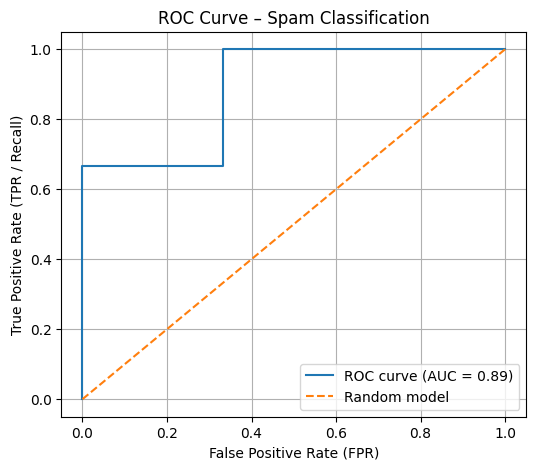

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Actual labels: 1 = spam, 0 = not spam
y_true = np.array([1, 1, 1, 0, 0, 0])
# Model predicted probabilities for "spam"
y_scores = np.array([0.90, 0.80, 0.40, 0.60, 0.30, 0.10])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(6, 5))

# ROC curve
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")

# Random guessing baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

# Labels and title
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title("ROC Curve – Spam Classification")
plt.legend()
plt.grid(True)

plt.show()

